In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sklearn.datasets
import seaborn as sns

In [2]:
x, y = sklearn.datasets.make_moons(200, noise=0.20)

In [3]:
x

array([[-5.66751976e-01,  3.26860385e-01],
       [ 9.74114372e-01,  1.15468848e-01],
       [-3.23625755e-01,  1.46342129e+00],
       [ 2.03382397e+00,  1.90993642e-01],
       [ 5.17943357e-01, -2.44518481e-01],
       [ 3.87068553e-01,  8.30464633e-01],
       [-7.83917127e-01,  5.23176965e-01],
       [-5.96082145e-01,  8.84253619e-01],
       [ 2.42166325e-01, -6.78864322e-02],
       [ 9.14211691e-01, -5.12053493e-01],
       [ 6.79402908e-01, -2.24234088e-01],
       [ 2.45829864e+00,  3.86339449e-01],
       [ 2.36606137e-01,  1.05528612e+00],
       [ 8.85220413e-01,  4.00682553e-01],
       [ 8.96386424e-01,  6.62114096e-01],
       [-6.60509777e-01,  9.05466210e-01],
       [ 1.72205713e+00, -4.00111842e-01],
       [ 1.61537569e+00, -2.16549849e-02],
       [ 4.27757129e-01,  5.53760306e-01],
       [ 1.26507079e+00, -6.73127526e-01],
       [ 9.77594275e-01, -4.58068700e-02],
       [-1.68329396e-01,  1.48140445e-01],
       [ 1.86767638e+00, -4.68579743e-02],
       [ 8.

In [4]:
y

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1])

<Axes: >

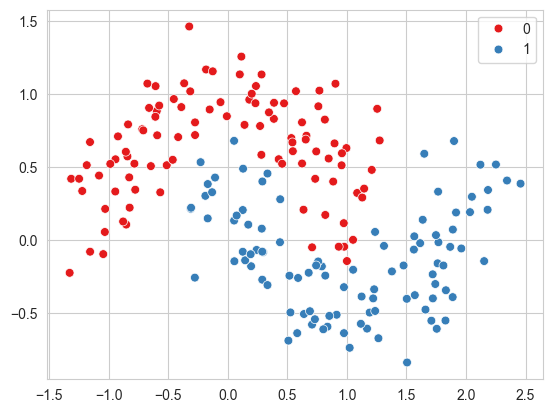

In [5]:
sns.scatterplot(x=x[:,0],y=x[:,1], hue=y, s=40, palette="Set1")

In [6]:
x = torch.FloatTensor(x)
y = torch.LongTensor(y)

In [7]:
class FeedForward(nn.Module):
    def __init__(self, input_neurons, hidden_neurons, output_neurons):
        super().__init__()
        self.hidden = nn.Linear(input_neurons, hidden_neurons)
        self.out = nn.Linear(hidden_neurons, output_neurons)
    def forward(self, x):
        x = self.hidden(x)
        x = F.relu(x)
        x = self.out(x)
        return x

In [8]:
network = FeedForward(2, 50, 2)
optimizer = torch.optim.SGD(network.parameters(), lr=0.02)
loss_function = nn.CrossEntropyLoss()

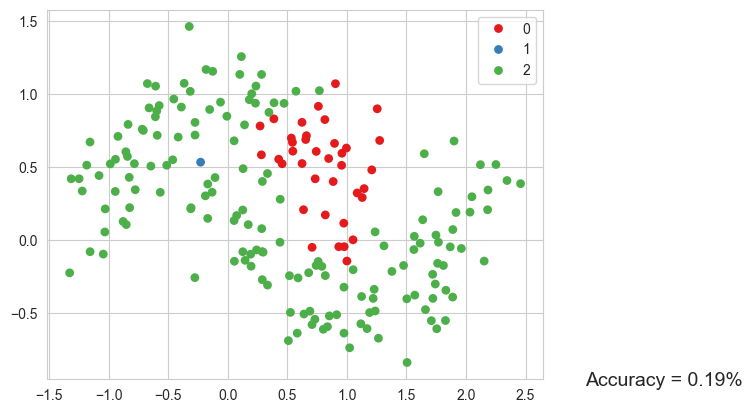

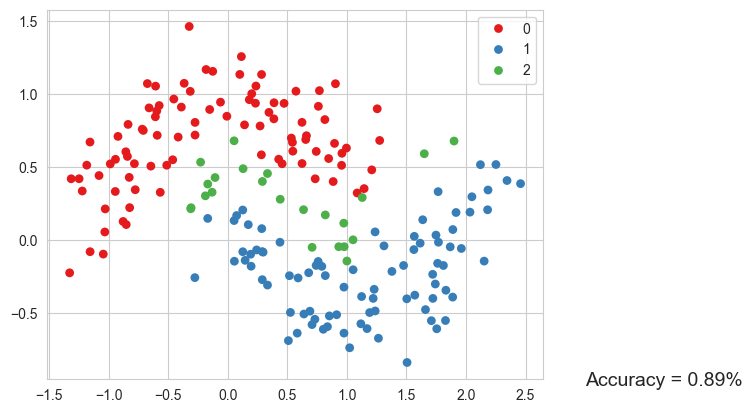

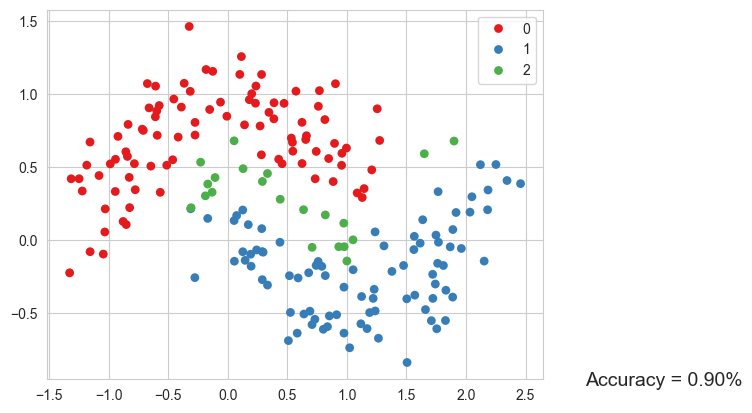

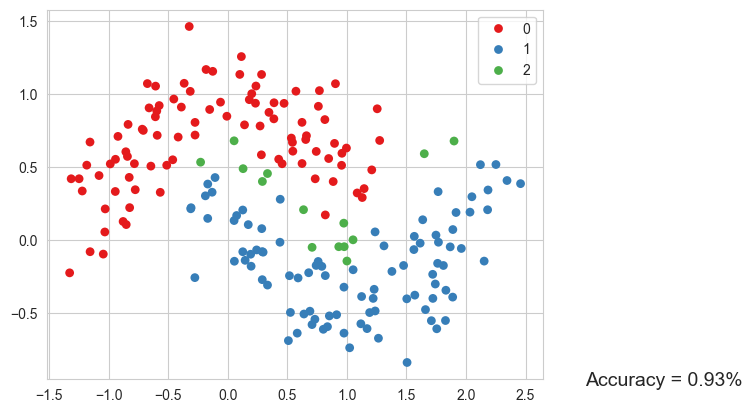

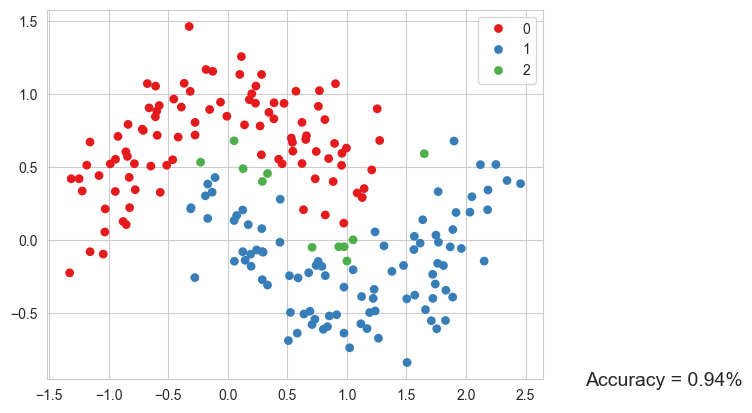

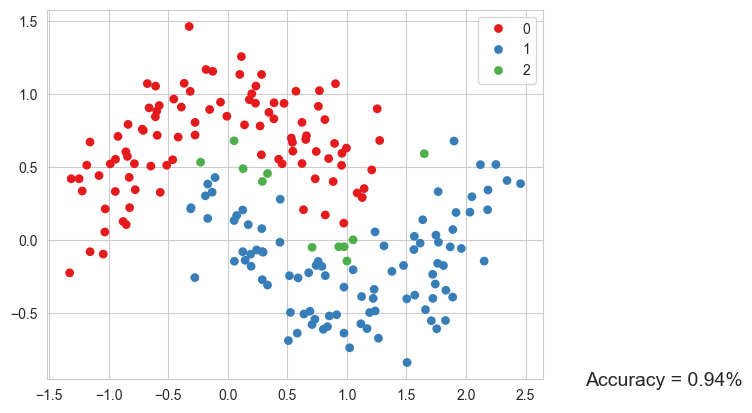

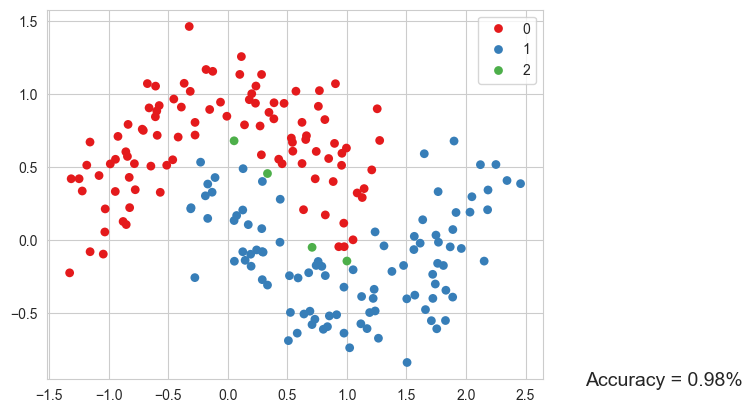

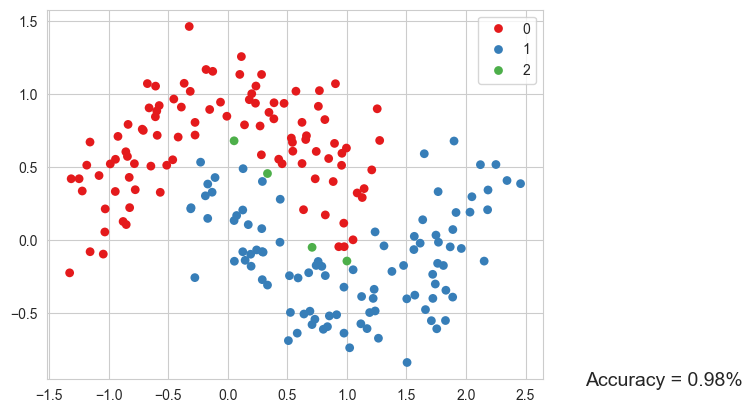

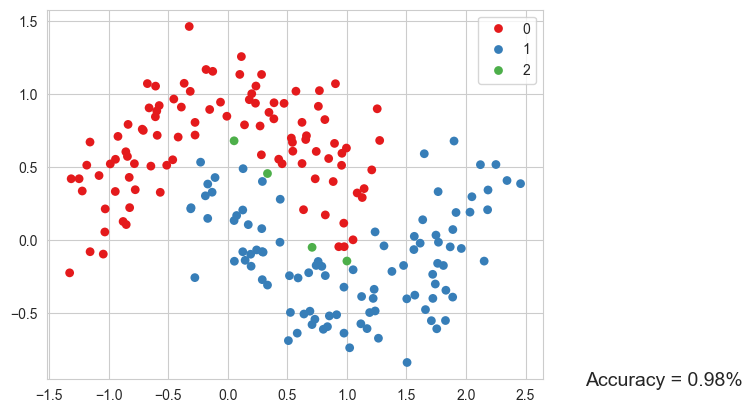

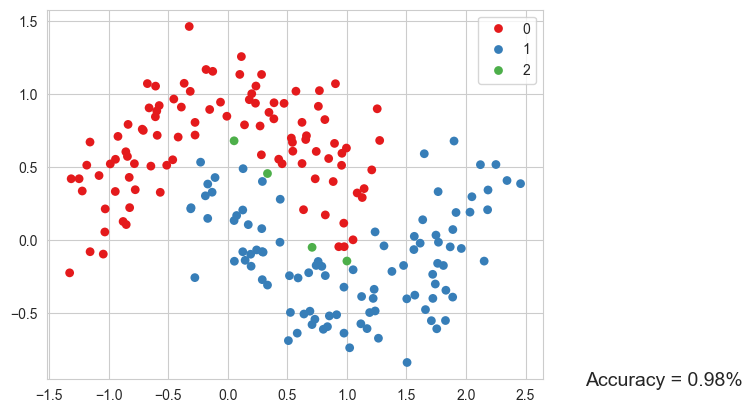

In [9]:
plt.ion()
for epoch in range(10000):
    out = network.forward(x)
    loss = loss_function(out, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Визуализация
    if epoch % 1000 == 0:
        max_value, prediction = torch.max(out, 1)
        predicted_y = prediction.data.numpy()
        target_y = y.data.numpy()
        for i in range(len(predicted_y)):
            predicted_y[i] = predicted_y[i] if predicted_y[i] == target_y[i] else 2
        sns.scatterplot(x=x.data.numpy()[:,0], y=x.data.numpy()[:, 1], s=40, hue=predicted_y, palette='Set1', lw=0)
        accuracy = (predicted_y == target_y).sum() / target_y.size
        plt.text(3, -1, f'Accuracy = {accuracy:.2f}%', fontdict={'size': 14})
        plt.pause(0.1)
plt.ioff()
plt.show()